# Costo del debito e rendimenti all'emissione

Questo notebook mette a confronto due concetti diversi:

- il costo del debito, cioe' gli interessi passivi delle Amministrazioni pubbliche rilevati da Eurostat;
- i rendimenti all'emissione di BOT e BTP, cioe' indicatori del costo di mercato sui nuovi collocamenti.

I rendimenti non sono il costo medio dello stock gia' emesso: servono per leggere le condizioni di mercato sulle nuove emissioni.

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

PRIMARY = "#1f77b4"
SECONDARY = "#d62728"
ACCENT = "#2ca02c"
MUTED = "#6b7280"
GRID = "#e5e7eb"
TEXT = "#111827"
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#cbd5e1",
    "axes.labelcolor": TEXT,
    "axes.titlecolor": TEXT,
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "text.color": TEXT,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
})


def repo_root():
    cwd = Path.cwd()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        if (candidate / "output" / "data" / "public" / "debito-pubblico.json").exists():
            return candidate
    raise FileNotFoundError("Eseguire prima: python scripts/build_all_datasets.py")


ROOT = repo_root()
DATA_FILE = ROOT / "output" / "data" / "public" / "debito-pubblico.json"

with DATA_FILE.open(encoding="utf-8") as file:
    payload = json.load(file)


def points_frame(record, value_index=2, value_name="value"):
    rows = record.get("points", []) if record else []
    df = pd.DataFrame(rows)
    if df.empty:
        return pd.DataFrame(columns=["date", value_name])
    df = df.rename(columns={0: "date", value_index: value_name})[["date", value_name]]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")
    return df.dropna().sort_values("date")


def euro_format(value, decimals=0):
    if value is None or pd.isna(value):
        return "ND"
    return f"{value:,.{decimals}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def format_mld_axis(value, pos):
    return euro_format(value, 0)


def format_pct_axis(value, pos):
    return f"{value:.0f}%".replace(".", ",")


def add_credit(fig, source):
    fig.text(
        0.01,
        0.01,
        f"Fonte: {source}. Elaborazione di Nazareno Lecis.",
        ha="left",
        va="bottom",
        color=MUTED,
        fontsize=9,
    )


def finish(ax, title, subtitle, source, ylabel=None, percent=False, format_y=True):
    fig = ax.figure
    ax.set_title(title, loc="left", fontsize=16, color=TEXT, pad=18)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=MUTED, fontsize=10, ha="left", va="bottom")
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", color=GRID, linewidth=0.8)
    ax.grid(True, axis="x", color=GRID, linewidth=0.5, alpha=0.55)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if format_y:
        if percent:
            ax.yaxis.set_major_formatter(FuncFormatter(format_pct_axis))
        else:
            ax.yaxis.set_major_formatter(FuncFormatter(format_mld_axis))
    add_credit(fig, source)
    fig.tight_layout(rect=[0, 0.05, 1, 0.94])
    return fig, ax


def latest_label(df, value_col, suffix):
    if df.empty:
        return "Ultimo dato non disponibile"
    row = df.iloc[-1]
    return f"Ultimo dato: {row['date'].date()} - {euro_format(row[value_col], 1)} {suffix}"

## Interessi passivi in valore nominale

La serie nominale mostra gli interessi passivi in miliardi di euro. E' utile per leggere l'onere di bilancio in termini assoluti.

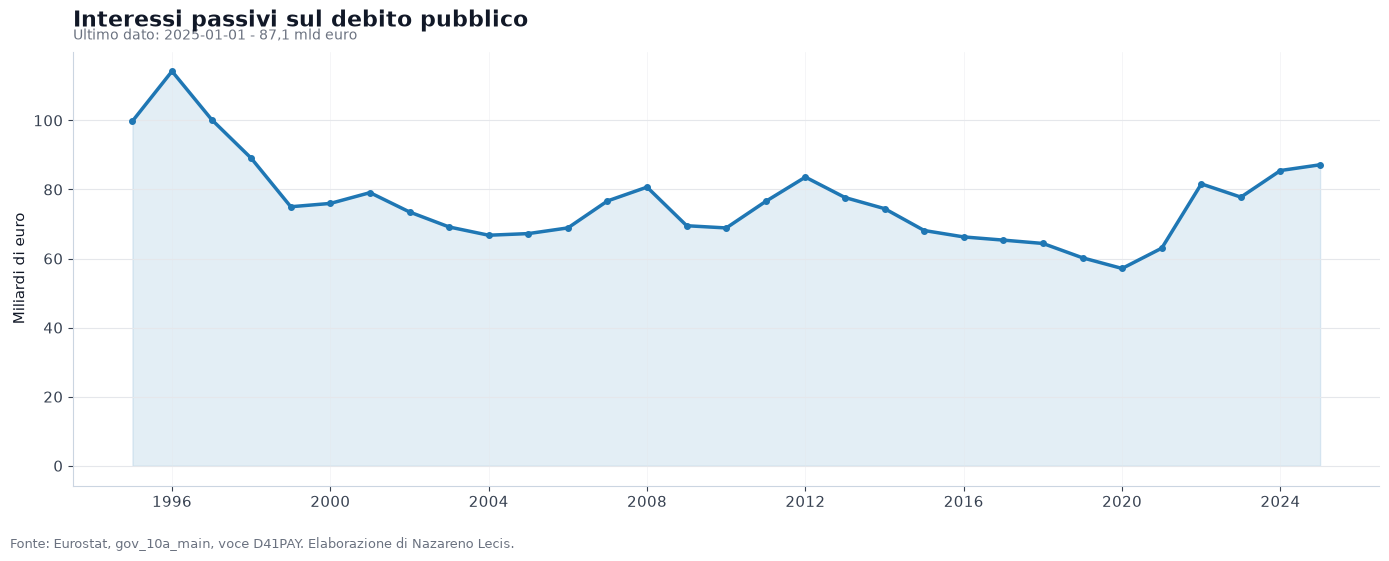

In [2]:
cost_nominal = points_frame(payload["debt_cost"]["measures"]["nominal"], value_index=2, value_name="mld_euro")
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(cost_nominal["date"], cost_nominal["mld_euro"], color=PRIMARY, linewidth=2.5, marker="o", markersize=4)
ax.fill_between(cost_nominal["date"], cost_nominal["mld_euro"], color=PRIMARY, alpha=0.12)
finish(
    ax,
    "Interessi passivi sul debito pubblico",
    latest_label(cost_nominal, "mld_euro", "mld euro"),
    "Eurostat, gov_10a_main, voce D41PAY",
    ylabel="Miliardi di euro",
)
plt.show()

## Interessi passivi in percentuale del PIL

La stessa voce puo' essere letta in rapporto al PIL. Questa misura aiuta a separare l'aumento nominale dell'economia dal peso relativo degli interessi.

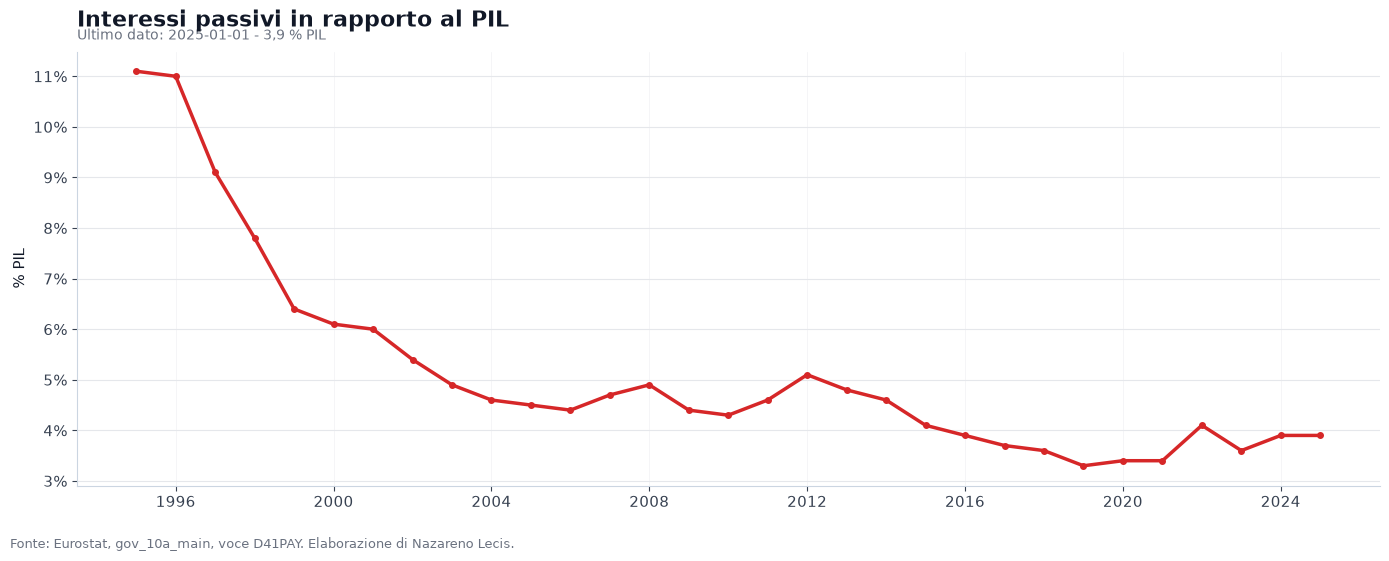

In [3]:
cost_gdp = points_frame(payload["debt_cost"]["measures"]["percent_gdp"], value_index=1, value_name="percent_gdp")
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(cost_gdp["date"], cost_gdp["percent_gdp"], color=SECONDARY, linewidth=2.5, marker="o", markersize=4)
finish(
    ax,
    "Interessi passivi in rapporto al PIL",
    latest_label(cost_gdp, "percent_gdp", "% PIL"),
    "Eurostat, gov_10a_main, voce D41PAY",
    ylabel="% PIL",
    percent=True,
)
plt.show()

## Rendimenti all'emissione per titolo

Il grafico confronta BOT 1 anno e BTP a 5, 10 e 20 anni. Per i BOT la fonte misura il tasso lordo di aggiudicazione; per i BTP misura il rendimento lordo all'emissione.

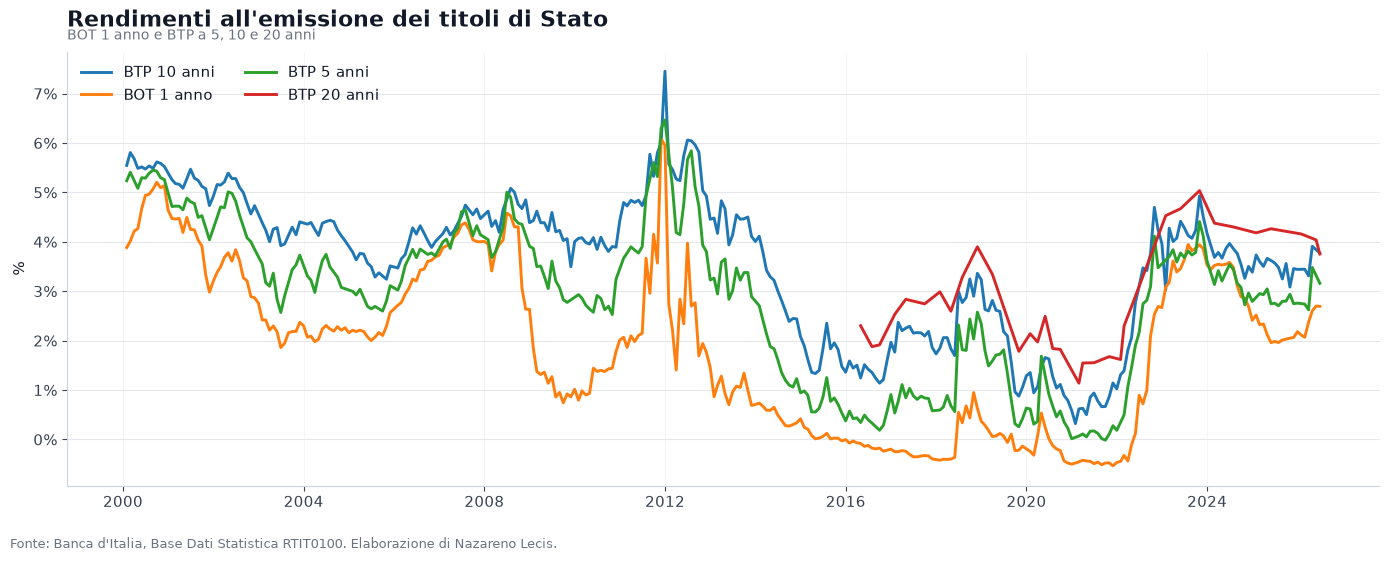

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
for index, series in enumerate(payload["security_yields"]["series"]):
    df = pd.DataFrame(series["points"], columns=["date", "value_percent"])
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["value_percent"] = pd.to_numeric(df["value_percent"], errors="coerce")
    df = df.dropna().sort_values("date")
    recent = df[df["date"].dt.year >= 2000]
    ax.plot(recent["date"], recent["value_percent"], label=series["label"], color=COLORS[index % len(COLORS)], linewidth=2.1)
ax.legend(loc="upper left", frameon=False, ncols=2)
finish(
    ax,
    "Rendimenti all'emissione dei titoli di Stato",
    "BOT 1 anno e BTP a 5, 10 e 20 anni",
    "Banca d'Italia, Base Dati Statistica RTIT0100",
    ylabel="%",
    percent=True,
)
plt.show()

## Lettura congiunta

Il costo del debito reagisce lentamente perche' riflette lo stock esistente e il calendario di rinnovo. I rendimenti all'emissione reagiscono piu' rapidamente alle condizioni di mercato e anticipano il costo marginale dei nuovi collocamenti.